<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/SERIES_TEMPORAIS_Previs%C3%A3o_de_Vendas_diarias_comp_modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho: Previsão de Vendas diária**

O objetivo principal é transformar dados transacionais em uma série temporal e realizar a previsão de vendas diárias para um departamento específico.

**1. Preparação dos Dados (Data Prep):**

Agregação: Converter as transações em uma série diária, utilizando a soma do valor das vendas como método de acumulação.

*   Saneamento
*   Datas Faltantes: Identificar lacunas no calendário e preenchê-las (imputação ou zero) para garantir que a série seja igualmente espaçada.
*  Vendas Negativas: Tratar valores negativos (erros de registro) por meio de imputação, como a média do período.

Foco da Análise: Priorizar os Departamentos 2 ou 4, que juntos representam cerca de 95% do faturamento total.

**2. Estratégia de Modelagem:**

Divisão da Base: Utilizar os anos de 2018, 2019 e 2020 para treino e o ano de 2021 para teste (Holdout).

Análise Inicial:

* Visualização: Plotar recortes da série para identificar tendência e sazonalidade.

* Testes Estatísticos: Validar se a série é Ruído Branco (se for, não há padrão para prever) e verificar a Estacionariedade.

**3. Execução e Avaliação:**

Escolha do Modelo: Identificar se há tendência e sazonalidade para selecionar a técnica adequada (Alisamento Exponencial Simples, Holt ou Holt-Winters).

Validação:
* Comparar os valores previstos com os reais da base de teste (2021).

* Calcular métricas de erro (como o MAPE) e garantir que os resíduos do modelo se comportem como ruído branco, provando que o sinal foi capturado corretamente.
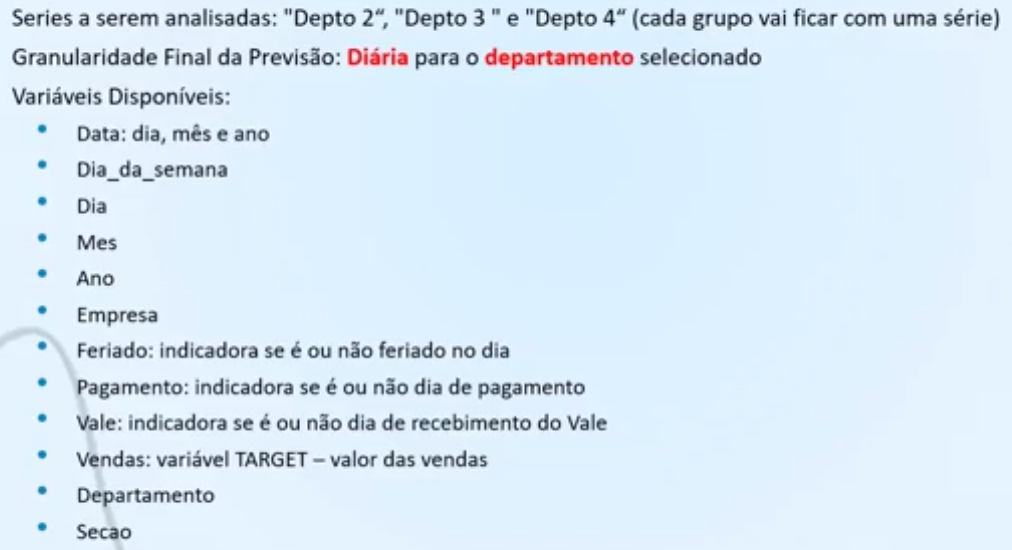

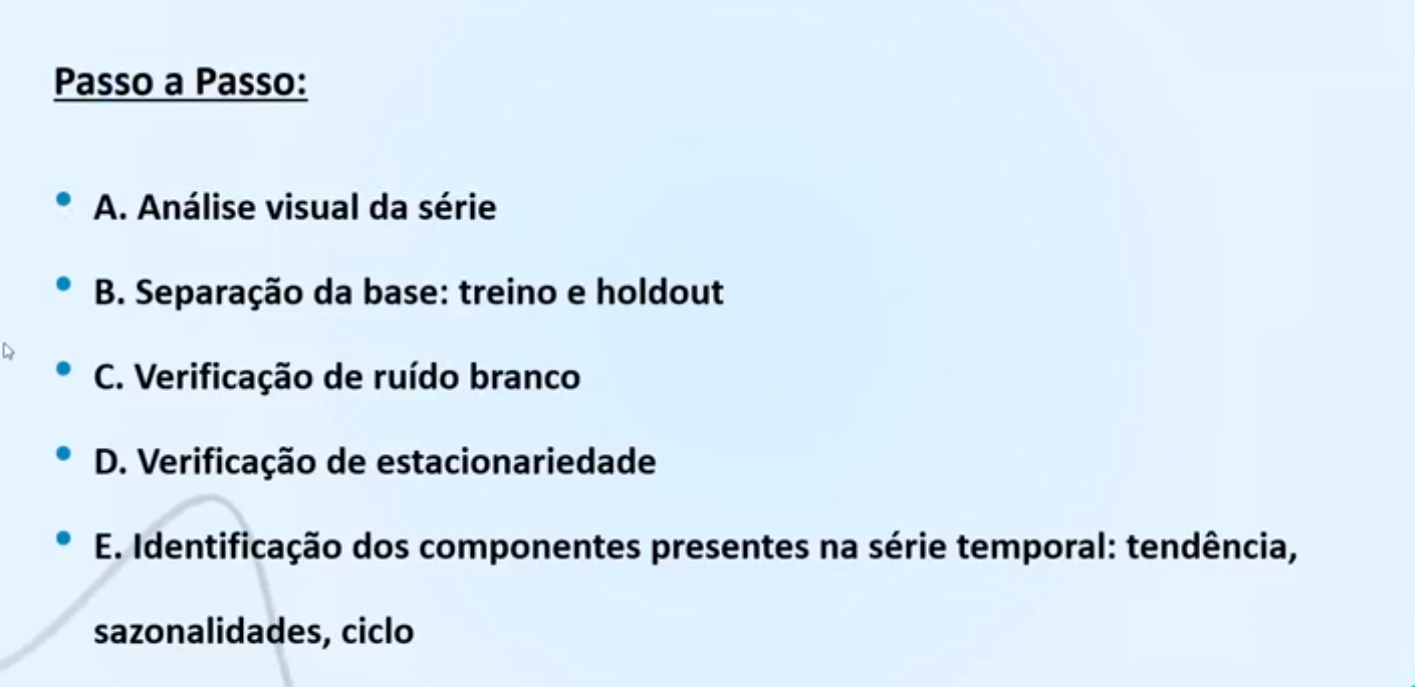

# **BIBLIOTECAS**

In [201]:
# Bibliotecas Básicas e Gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels - Ferramentas de Análise e Testes
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Statsmodels - Modelos de Previsão (Passo F)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Métricas de Avaliação (Passo I) - CORRIGIDO
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from math import sqrt

# Configurações de Gráficos
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

print('✅ Bibliotecas essenciais carregadas e prontas para o passo a passo!')

✅ Bibliotecas essenciais carregadas e prontas para o passo a passo!


# **1. CARREGAR DADOS**

In [162]:
!pip install gdown # ponte entre Google Drive e Python

In [163]:
import gdown

file_id = "1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "Vendas_ASN_Dados_Finais.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW
To: /content/Vendas_ASN_Dados_Finais.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 93.9MB/s]


'Vendas_ASN_Dados_Finais.csv'

In [164]:
data = pd.read_csv('Vendas_ASN_Dados_Finais.csv')
data.head(10)

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,01/02/18,1/2/2018,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,01/02/18,1/2/2018,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [165]:
# ver formato que está a data
data['Data_new'].dtype

dtype('O')

In [166]:
data['Data'].dtype

dtype('O')

In [167]:
# Deixar a data no formato de data, e não de object
data['Data'] = pd.to_datetime(pd.DataFrame({
    'day': data['Dia'],
    'month': data['Mes'],
    'year': data['Ano']
}))

In [168]:
data.head(10)

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,2018-01-02,1/2/2018,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,2018-01-02,1/2/2018,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [169]:
data['Data'].dtype

dtype('<M8[ns]')

# **2. TRANSFORMAR DADOS TRANSACIONAIS EM AGREGADOS**

Método de acumulação - soma

Intervalo de tempo - diária

In [170]:
data['Vendas'] = (
    data['Vendas']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# QUANTAS VENDAS TEM POR DEPARTAMENTO?

total_departamento = (
    data.groupby('Departamento', as_index=False)['Vendas']
      .sum()
)

# Total geral
total_geral = total_departamento['Vendas'].sum()

# Percentual de participação
total_departamento['Perc'] = (
    total_departamento['Vendas'] / total_geral * 100
)

# Valor em milhões
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas'] / 1_000_000
)

# Formatação
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas_MM']
    .map(lambda x: f'{x:,.2f} MM')
)

total_departamento['Perc'] = (
    total_departamento['Perc']
    .map(lambda x: f'{x:.2f}%')
)

print(total_departamento)

  Departamento        Vendas    Perc    Vendas_MM
0      Depto 1  5.295840e+06   0.09%      5.30 MM
1      Depto 2  3.265787e+09  54.12%  3,265.79 MM
2     Depto 3   2.474437e+08   4.10%    247.44 MM
3      Depto 4  2.460234e+09  40.77%  2,460.23 MM
4      Depto 5  5.052954e+07   0.84%     50.53 MM
5      Depto 6  4.219464e+06   0.07%      4.22 MM
6      Depto 7  9.759944e+05   0.02%      0.98 MM


Para continuar a análise, foi escolhido o departamento 4 por representar 41% das vendas.

In [171]:
# Filtrar apenas o Depto 4
data_depto4 = data[data['Departamento'] == 'Depto 4']

# Verificar se existe alguma venda negativa
tem_negativo = (data_depto4['Vendas'] < 0).any()
print("Existe venda negativa?", tem_negativo)

# Listar todas as linhas com vendas negativas
vendas_negativas = data_depto4[data_depto4['Vendas'] < 0]
print(vendas_negativas)

Existe venda negativa? True
             Data    Data_new  Dia_da_semana  Dia  Mes   Ano  Empresa  \
288456 2020-11-23  11/23/2020              2   23   11  2020       23   

        Feriado  Pagamento  Vale  Vendas Departamento     Seção  
288456        0          0     0   -5.66      Depto 4  Seção 20  


In [172]:
# Substituir as linhas negativas

df_depto = data[data['Departamento'] == 'Depto 4'].copy()

# 2. Identificar dinamicamente os índices de todas as linhas que contêm vendas negativas
indices_com_erro = df_depto[df_depto['Vendas'] < 0].index

if len(indices_com_erro) > 0:
    print(f"Detectadas {len(indices_com_erro)} linhas com vendas negativas.")

    # 3. Iterar de forma puramente dinâmica sobre os índices com erro
    for idx in indices_com_erro:
        # Extrai o mês e o ano DIRETAMENTE da linha que apresentou o erro
        mes_dinamico = df_depto.loc[idx, 'Mes']
        ano_dinamico = df_depto.loc[idx, 'Ano']
        valor_original = df_depto.loc[idx, 'Vendas']

        # Filtra a base para calcular a média apenas das vendas válidas (>= 0)
        # do mesmo mês e ano que foram identificados acima
        filtro_periodo_valido = (
            (df_depto['Mes'] == mes_dinamico) &
            (df_depto['Ano'] == ano_dinamico) &
            (df_depto['Vendas'] >= 0)
        )
        media_periodo = df_depto.loc[filtro_periodo_valido, 'Vendas'].mean()

        # Substitui o valor negativo na linha exata usando o índice
        df_depto.loc[idx, 'Vendas'] = media_periodo
        print(f"   Período identificado: {mes_dinamico:02d}/{ano_dinamico}")
        print(f"   Valor corrigido de {valor_original} para a média de {media_periodo:.2f}\n")
else:
    print("Nenhum valor negativo encontrado. A base está limpa!")

# 4. Validação final automática
restou_negativo = (df_depto['Vendas'] < 0).any()
print("Ainda existem valores negativos na série?", restou_negativo)

Detectadas 1 linhas com vendas negativas.
   Período identificado: 11/2020
   Valor corrigido de -5.66 para a média de 34666.02

Ainda existem valores negativos na série? False


In [173]:
df_depto

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
20,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,73241.03,Depto 4,Seção 18
21,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,71675.73,Depto 4,Seção 19
22,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,120764.96,Depto 4,Seção 20
23,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,90562.58,Depto 4,Seção 21
24,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,4934.41,Depto 4,Seção 22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
306996,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,36454.57,Depto 4,Seção 19
306997,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,46405.58,Depto 4,Seção 20
306998,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,55328.16,Depto 4,Seção 21
307000,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,77382.53,Depto 4,Seção 18


In [174]:
vendas_dia = (
    data_depto4.groupby(['Data'])['Vendas']
      .sum()
      .reset_index()
)

print(vendas_dia)


           Data      Vendas
0    2018-01-02  1812134.19
1    2018-01-03  1622115.60
2    2018-01-04  1486888.42
3    2018-01-05  2015469.36
4    2018-01-06  2678387.64
...         ...         ...
1143 2021-02-24  2025751.85
1144 2021-02-25  2216224.47
1145 2021-02-26  3098829.40
1146 2021-02-27  4592539.97
1147 2021-02-28  2157356.38

[1148 rows x 2 columns]


In [175]:
# ANÁLISE DA VARIÁVEL VENDA:

vendas_dia['Vendas'].describe()

,Vendas
count,1.148000e+03
mean,2.143061e+06
std,7.398696e+05
min,5.802061e+05
25%,1.632986e+06
50%,1.954044e+06
75%,2.459384e+06
max,5.363986e+06


In [176]:
vendas_dia['Ano'] = vendas_dia['Data'].dt.year

vendas_dia.head(10)

,Data,Vendas,Ano
0,2018-01-02,1812134.19,2018
1,2018-01-03,1622115.60,2018
2,2018-01-04,1486888.42,2018
3,2018-01-05,2015469.36,2018
4,2018-01-06,2678387.64,2018
5,2018-01-07,1120660.99,2018
6,2018-01-08,1600882.79,2018
7,2018-01-09,1963629.68,2018
8,2018-01-10,1667902.81,2018
9,2018-01-11,1457775.73,2018


In [177]:
vendas_dia_temp = vendas_dia.set_index('Data')
data_inicio = vendas_dia_temp.index.min()
data_fim = vendas_dia_temp.index.max()
calendario_completo = pd.date_range(start=data_inicio, end=data_fim, freq='D')

vendas_reindexado = vendas_dia_temp.reindex(calendario_completo)
datas_faltantes = vendas_reindexado[vendas_reindexado['Vendas'].isna()].index

print(f"Havia um total de {len(datas_faltantes)} datas faltantes na série original.")
if len(datas_faltantes) > 0:
    print("\n--- Lista das datas faltantes identificadas ---")
    for data_faltante in datas_faltantes:
        print(data_faltante.date())
else:
    print("\nNenhuma data faltante encontrada!")

# Criar a nova série substituindo os NaNs por 0.000001 de forma explícita
vendas_dia_completo = vendas_reindexado.copy()
vendas_dia_completo['Vendas'] = vendas_dia_completo['Vendas'].fillna(1)

# Renomear o índice para 'Data' para manter o padrão limpo
vendas_dia_completo.index.name = 'Data'

print("\n--- Verificação após a substituição ---")
print(f"Quantidade de NaNs restantes: {vendas_dia_completo['Vendas'].isna().sum()}")
print(f"Quantidade de dias com valor 0.000001: {(vendas_dia_completo['Vendas'] == 0.000001).sum()}")
print(f"Havia um total de {total_faltantes} datas faltantes (buracos no calendário) na série original.")

Havia um total de 6 datas faltantes na série original.

--- Lista das datas faltantes identificadas ---
2018-12-25
2019-01-01
2019-12-25
2020-01-01
2020-12-25
2021-01-01

--- Verificação após a substituição ---
Quantidade de NaNs restantes: 0
Quantidade de dias com valor 0.000001: 0
Havia um total de 6 datas faltantes (buracos no calendário) na série original.


In [178]:
vendas_dia_completo

,Vendas,Ano
Data,,
2018-01-02,1812134.19,2018.0
2018-01-03,1622115.60,2018.0
2018-01-04,1486888.42,2018.0
2018-01-05,2015469.36,2018.0
2018-01-06,2678387.64,2018.0
...,...,...
2021-02-24,2025751.85,2021.0
2021-02-25,2216224.47,2021.0
2021-02-26,3098829.40,2021.0


In [179]:
vendas_dia_completo = vendas_dia_completo.reset_index()

In [180]:
vendas_dia_completo['Data'].dtype

dtype('<M8[ns]')

In [181]:
vendas_dia_completo['Data'] = pd.to_datetime(vendas_dia_completo['Data'])

# **3. ANÁLISE VISUAL E IDENTIFICAÇÃO DE COMPONENTES**

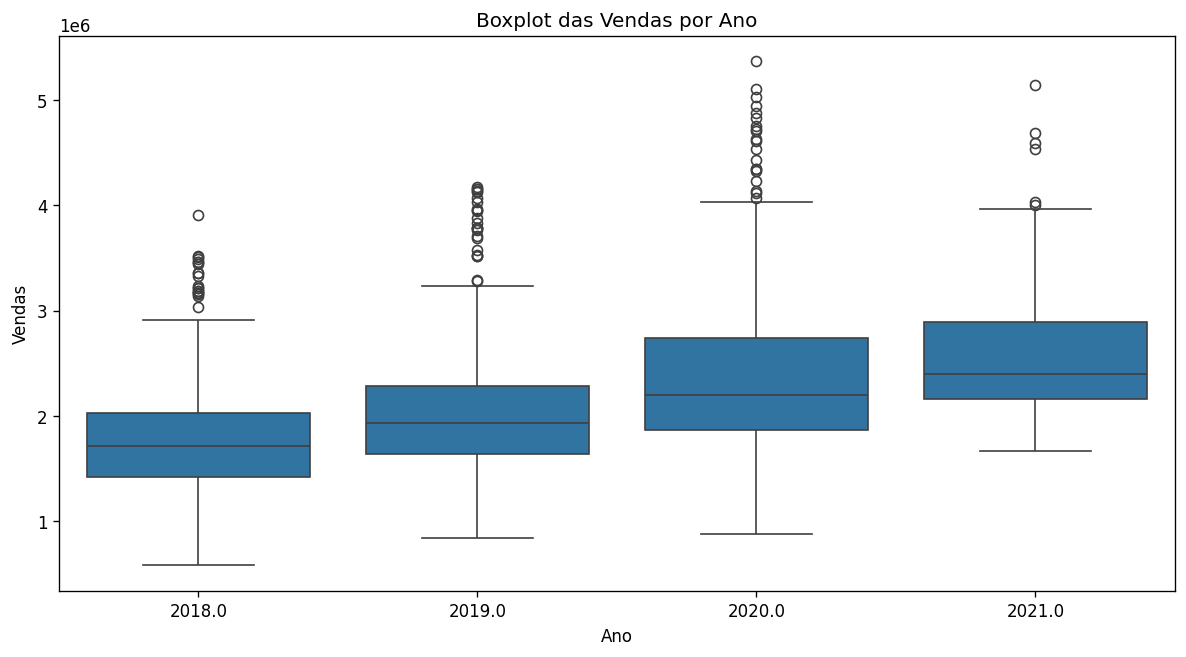

In [182]:
# BOXPLOT AO LONGO DOS ANOS:

fig, ax = plt.subplots(figsize=(12,6))

sns.boxplot(
    data=vendas_dia_completo,
    x='Ano',
    y='Vendas',
    ax=ax
)

plt.title('Boxplot das Vendas por Ano')
plt.show()

In [183]:
vendas_dia_completo.groupby('Ano')['Vendas'].describe()

,count,mean,std,min,25%,50%,75%,max
Ano,,,,,,,,
2018.0,363.0,1.827837e+06,579069.807873,580206.06,1.415357e+06,1710038.510,2.025495e+06,3906138.25
2019.0,363.0,2.089768e+06,640858.788881,836348.22,1.637741e+06,1932448.020,2.283950e+06,4168269.68
2020.0,364.0,2.427573e+06,814747.069522,878158.71,1.863710e+06,2201581.005,2.734793e+06,5363986.16
2021.0,58.0,2.663906e+06,778574.868966,1667474.63,2.161169e+06,2399303.330,2.891777e+06,5141515.66


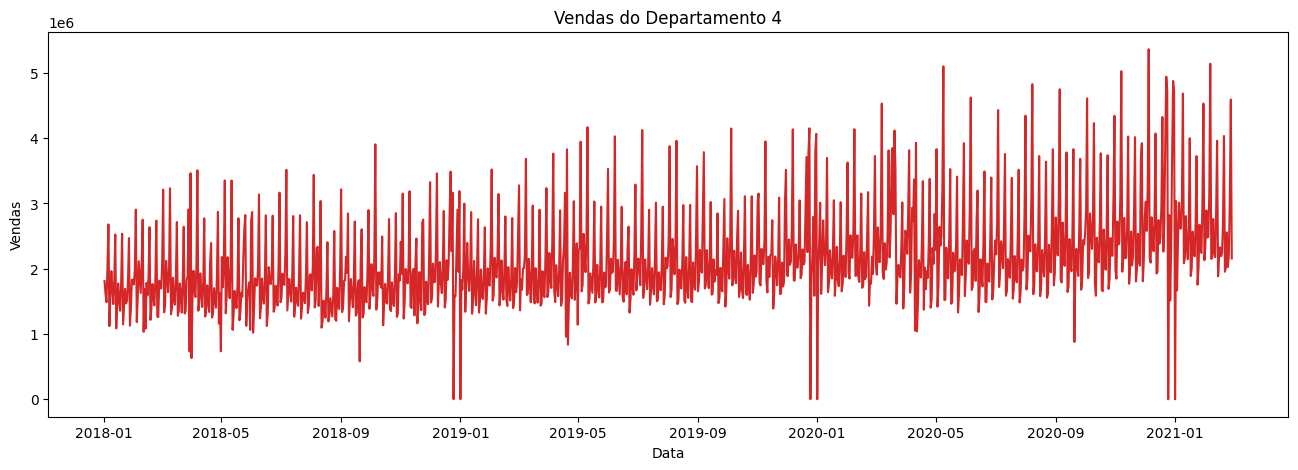

In [184]:
# Visualizando a série temporal

def plot_df(vendas_dia_completo, x, y, title="", xlabel='Data', ylabel='Vendas', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(
    vendas_dia_completo=vendas_dia_completo,
    x=vendas_dia_completo['Data'],
    y=vendas_dia_completo['Vendas'],
    title='Vendas do Departamento 4'
)

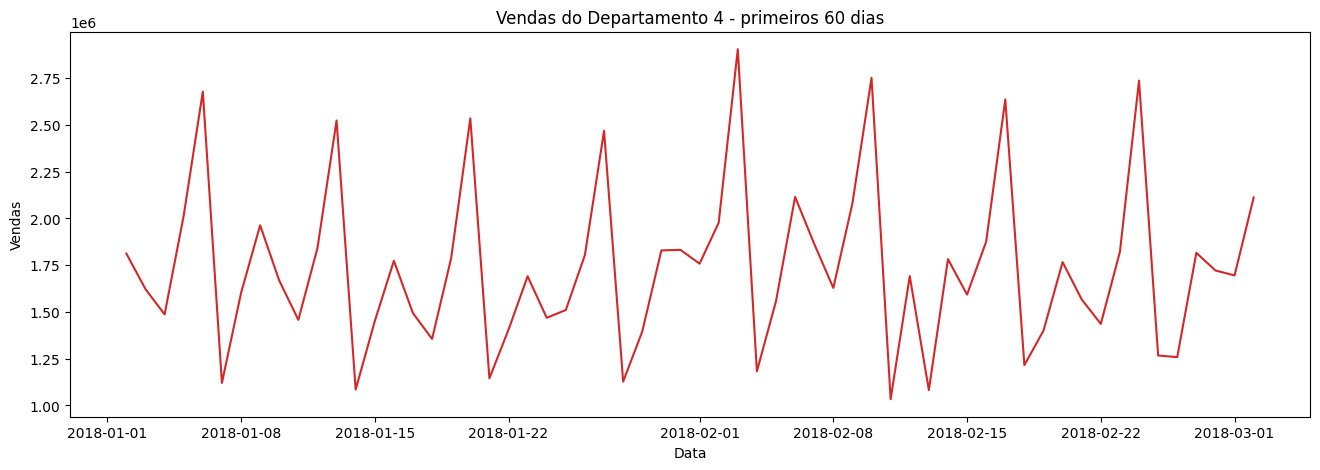

In [185]:
# Visualizando a série temporal em um intervalo de tempo menor

vendas_dia_completo = vendas_dia_completo.sort_values('Data')

trecho = vendas_dia_completo.iloc[:60]

plot_df(
    vendas_dia_completo=trecho,
    x=trecho['Data'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - primeiros 60 dias'
)

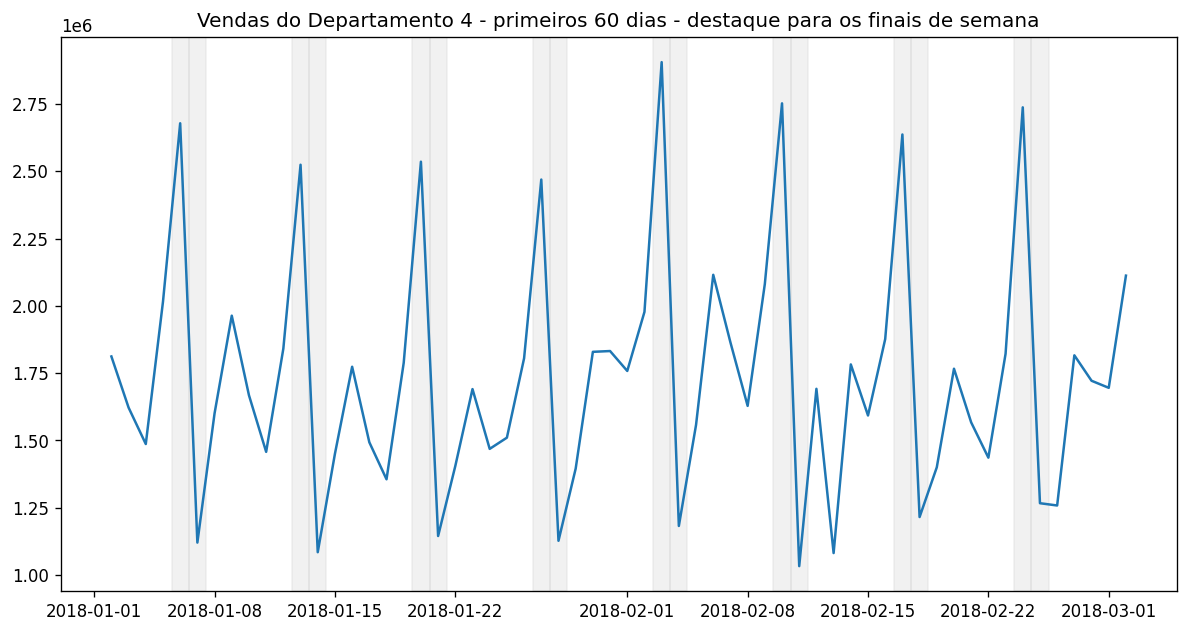

In [186]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(trecho['Data'], trecho['Vendas'])

# destacar finais de semana
for data in trecho.loc[trecho['Data'].dt.dayofweek >= 5, 'Data']:
    ax.axvspan(
        data - pd.Timedelta(hours=12),
        data + pd.Timedelta(hours=12),
        color='lightgray',
        alpha=0.3
    )
ax.set_title('Vendas do Departamento 4 - primeiros 60 dias - destaque para os finais de semana')
plt.show()

A série temporal apresenta comportamento predominantemente estacionário, sem tendência definida no período analisado. Observam-se oscilações diárias em torno de um nível médio aproximadamente constante, acompanhadas de elevada variabilidade e indícios de sazonalidade de curta duração, possivelmente semanal.

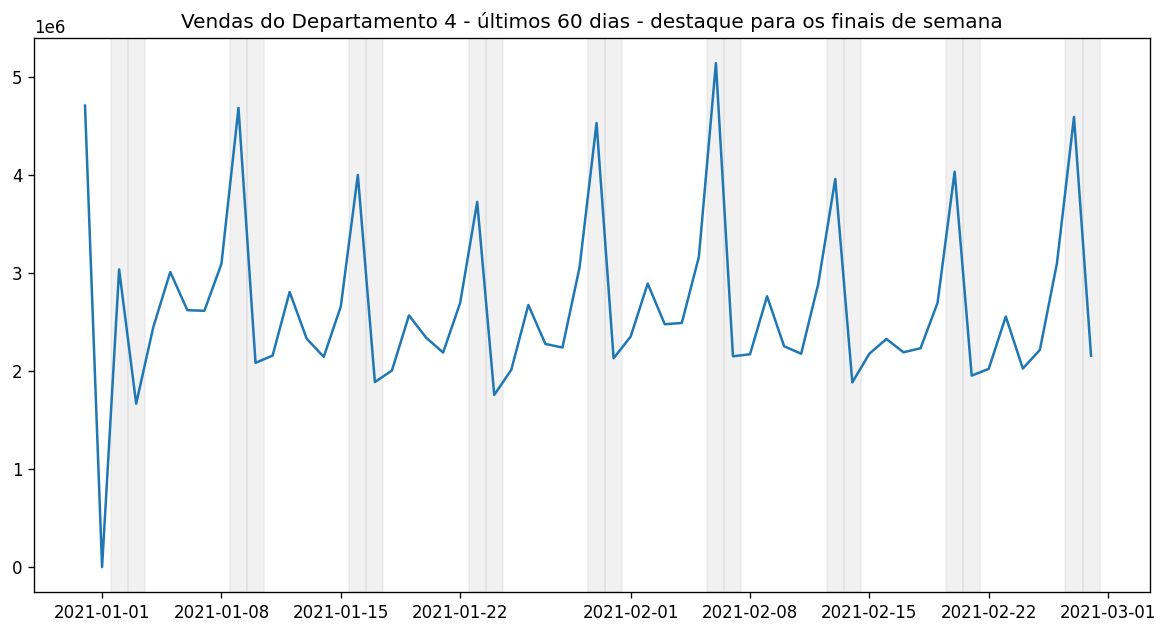

In [187]:
trecho_fim = vendas_dia_completo.tail(60)

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(trecho_fim['Data'], trecho_fim['Vendas'])

for data in trecho_fim.loc[trecho_fim['Data'].dt.dayofweek >= 5, 'Data']:
    ax.axvspan(
        data - pd.Timedelta(hours=12),
        data + pd.Timedelta(hours=12),
        color='lightgray',
        alpha=0.3
    )

ax.set_title('Vendas do Departamento 4 - últimos 60 dias - destaque para os finais de semana')
plt.show()

DECOMPOSIÇÃO MULTIPLICATIVA DA SÉRIE:

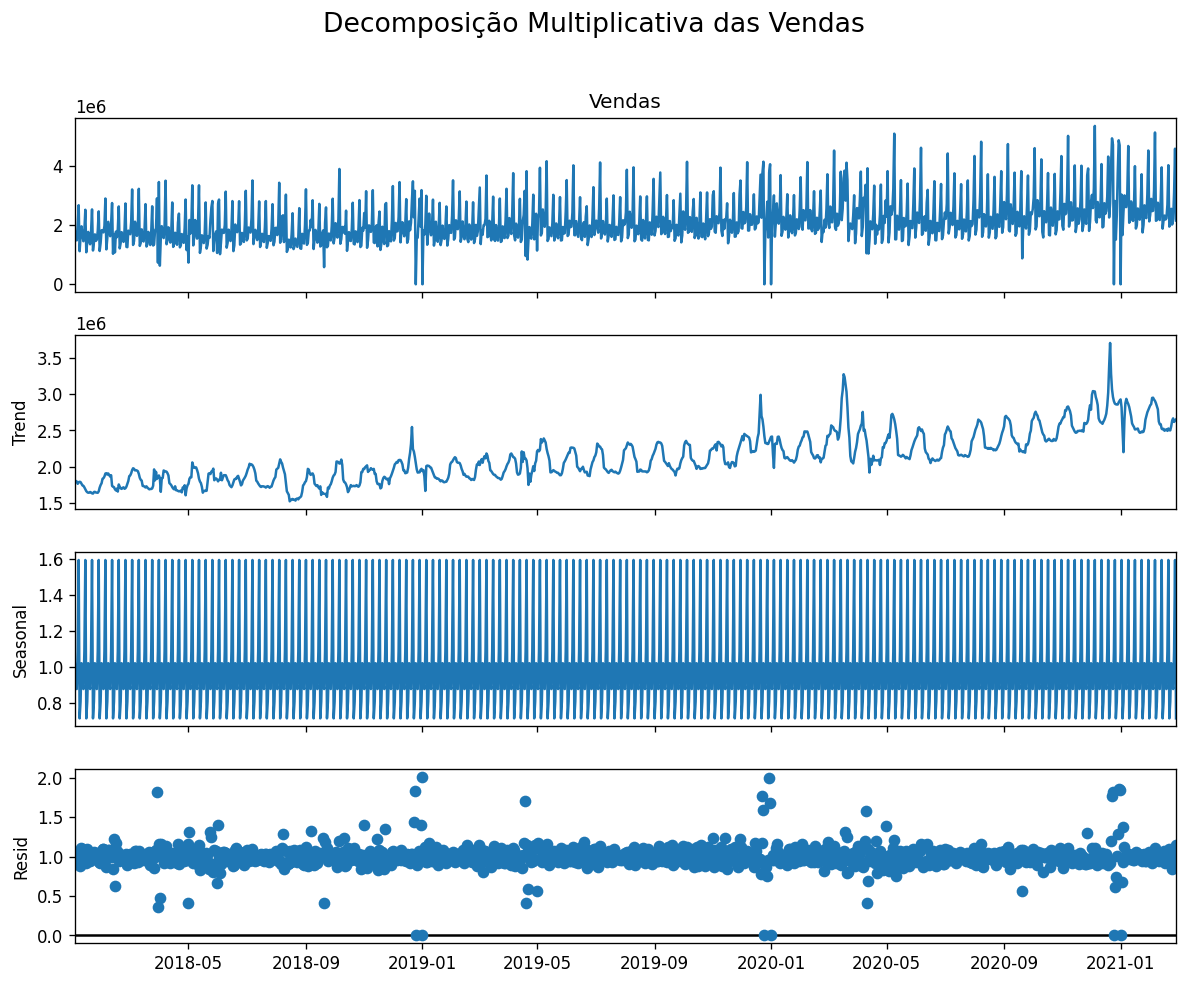

In [188]:
# PADRÃO SEMANAL
from statsmodels.tsa.seasonal import seasonal_decompose

# Definimos a Data como índice temporariamente e extraímos apenas a coluna 'Vendas'
serie_temporal = vendas_dia_completo.set_index('Data')['Vendas']

# Executar a decomposição multiplicativa na série ajustada
result_mul = seasonal_decompose(
    serie_temporal,
    model='multiplicative',
    period=7,  # sazonalidade semanal
    extrapolate_trend='freq'
)

# Configurar e plotar os gráficos dos componentes (Tendência, Sazonalidade e Ruído)
plt.rcParams.update({'figure.figsize': (10, 8)})

result_mul.plot()

# Adiciona o título global corretamente
plt.suptitle(
    'Decomposição Multiplicativa das Vendas',
    fontsize=16,
    y=1.02 # Ajusta a altura para não sobrepor o gráfico superior
)

plt.tight_layout()
plt.show()

A decomposição multiplicativa confirma que a série temporal de vendas do Departamento 4 possui uma tendência de alta consistente de longo prazo (saindo de patamares próximos a 1,7 milhão em 2018 e superando 2,5 milhões a partir de 2020) e uma sazonalidade semanal altamente marcante, com fatores multiplicativos que variam de 0,7 a 1,6 vezes o valor da tendência conforme o dia da semana. O gráfico dos resíduos demonstra estabilidade geral ao redor do valor 1,0, o que valida a escolha do modelo multiplicativo, evidenciando apenas variações extremas pontuais perto de zero nas viradas de ano, causadas pelo preenchimento dos dias em que não houve faturamento registrado.

Em resumo, foi identificado por meio do Boxplot e da Decomposição:

*   Tendência: Sim, de alta ao longo dos anos.
*   Sazonalidade: Sim, fortemente semanal (período = 7).
*   Ciclo: Não há ciclos de longo prazo visíveis (como ciclos econômicos de vários anos).

# **4. SEPARAÇÃO DA SÉRIE ENTRE TREINO E TESTE**

In [189]:
df_temporario = vendas_dia_completo.set_index('Data')

# Divisão conforme as regras do exercício da DSA
treino = df_temporario.loc[:'2020-12-31']
holdout = df_temporario.loc['2021-01-01':'2021-02-28']

print(f"Base de Treinamento: {len(treino)} dias (até {treino.index.max().date()})")
print(f"Base de Holdout: {len(holdout)} dias (de {holdout.index.min().date()} até {holdout.index.max().date()})")

Base de Treinamento: 1095 dias (até 2020-12-31)
Base de Holdout: 59 dias (de 2021-01-01 até 2021-02-28)


# **5. VERIFICAÇÃO DE RUÍDO BRANCO (NA BASE DE TREINO)**

In [190]:
# Testando se a série de treino é aleatória (Ruído Branco)
resultado_lb = acorr_ljungbox(treino['Vendas'], lags=[7], return_df=True)

print("--- TESTE DE LJUNG-BOX ---")
print(resultado_lb)

p_valor_lb = resultado_lb['lb_pvalue'].values[0]
if p_valor_lb < 0.05:
    print(f"\np-valor = {p_valor_lb:.5f} (< 0.05). Rejeitamos a hipótese nula!")
    print("A série NÃO é ruído branco. Podemos seguir com a modelagem. 🚀")
else:
    print("\nA série é ruído branco. Não há padrões previsíveis.")

--- TESTE DE LJUNG-BOX ---
      lb_stat      lb_pvalue
7  790.683433  1.900542e-166

p-valor = 0.00000 (< 0.05). Rejeitamos a hipótese nula!
A série NÃO é ruído branco. Podemos seguir com a modelagem. 🚀


# **6. VERIFICAÇÃO DE ESTACIONARIEDADE (Na Base de Treino)**

In [191]:
resultado_adf = adfuller(treino['Vendas'])

print("--- PASSO D: TESTE DE ESTACIONARIEDADE (ADF) ---")
print(f"Estatística ADF: {resultado_adf[0]:.4f}")
print(f"p-valor: {resultado_adf[1]:.5f}")
print("\nValores Críticos de Controle:")
for chave, valor in resultado_adf[4].items():
    print(f"   {chave}: {valor:.4f}")

# Validação do p-valor
if resultado_adf[1] < 0.05:
    print("\nAnálise: p-valor < 0.05. A série já é ESTACIONÁRIA! (d = 0) 🎯")
else:
    print("\nAnálise: p-valor >= 0.05. A série NÃO é estacionária. Precisaremos aplicar diferenciação (d >= 1). ⚠️")

--- PASSO D: TESTE DE ESTACIONARIEDADE (ADF) ---
Estatística ADF: -1.5772
p-valor: 0.49501

Valores Críticos de Controle:
   1%: -3.4365
   5%: -2.8642
   10%: -2.5682

Análise: p-valor >= 0.05. A série NÃO é estacionária. Precisaremos aplicar diferenciação (d >= 1). ⚠️


# **7. VERIFICAÇÃO DE SAZONALIDADE**

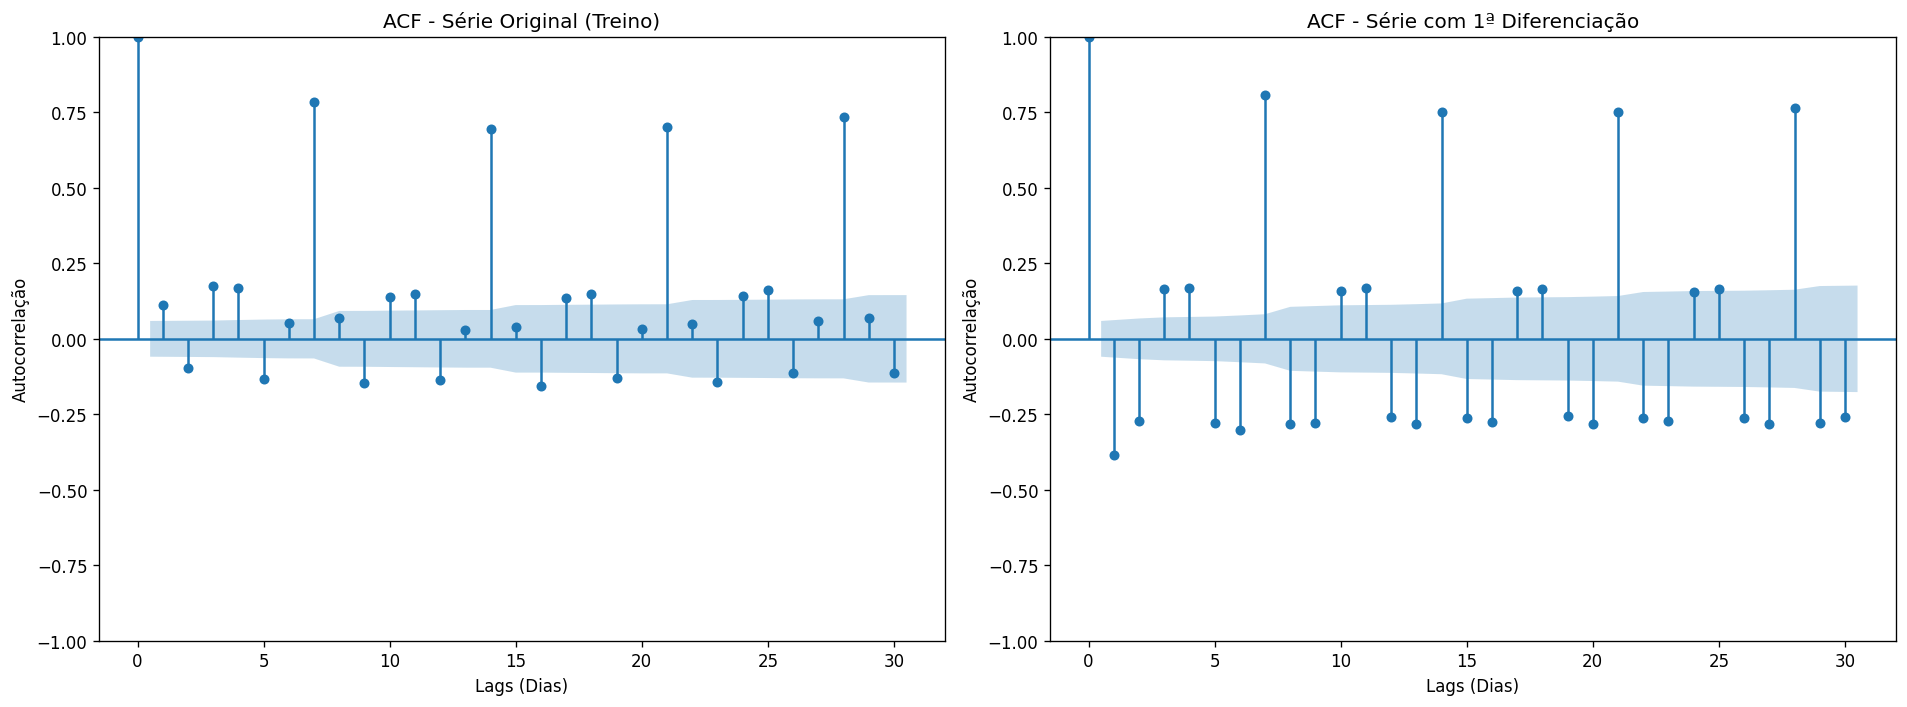

In [202]:
# Verificando autocorrelação
# Usando função ACF

# Criando a estrutura de subplots (lado a lado)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. ACF da Série Original (Treino)
# Mostra o efeito da tendência + sazonalidade
plot_acf(treino['Vendas'], lags=30, ax=ax1, title="ACF - Série Original (Treino)")
ax1.set_xlabel("Lags (Dias)")
ax1.set_ylabel("Autocorrelação")

# 2. ACF da Série Diferenciada (Removendo a tendência)
# Mostra puramente a sazonalidade isolada
plot_acf(treino['Vendas'].diff().dropna(), lags=30, ax=ax2, title="ACF - Série com 1ª Diferenciação")
ax2.set_xlabel("Lags (Dias)")
ax2.set_ylabel("Autocorrelação")

plt.tight_layout()
plt.show()

Os gráficos de autocorrelação (ACF) confirmam e provam matematicamente a forte presença de sazonalidade semanal na série de vendas do Departamento 4. Enquanto o primeiro gráfico exibe barras persistentemente altas devido à tendência de longo prazo já identificada, o segundo gráfico — gerado após a aplicação da primeira diferenciação para estabilizar a média — isola o comportamento sazonal de forma cristalina, destacando picos intensos e significativos fora da área sombreada de controle exatamente nos lags 7, 14, 21 e 28. Essa repetição exata a cada sete dias valida estatisticamente que o volume de vendas do dia atual é fortemente dependente e correlacionado com o que aconteceu no mesmo dia da semana anterior, justificando tecnicamente o uso de modelagens sazonais (como Holt-Winters e SARIMA com período igual a 7) para o pipeline preditivo.

# **8. MODELOS**

## **8.1 Família Alisamento Exponencial: Holt-Winters Multiplicativo:**



In [193]:
# Ajustando o modelo Holt-Winters na base de treino
modelo_hw = ExponentialSmoothing(
    treino['Vendas'],
    trend='mul',        # Tendência multiplicativa
    seasonal='mul',     # Sazonalidade multiplicativa
    seasonal_periods=7  # Período semanal
).fit()

# Prevendo para o período exato do holdout
passos_holdout = len(holdout)
previsao_hw = modelo_hw.forecast(steps=passos_holdout)
previsao_hw.index = holdout.index

print("--- HOLT-WINTERS Multiplicativo---")
print(f"Previsões geradas para os {passos_holdout} dias do período holdout!")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


--- HOLT-WINTERS Multiplicativo---
Previsões geradas para os 59 dias do período holdout!


In [206]:
print(modelo_hw.summary())

                        ExponentialSmoothing Model Results                       
Dep. Variable:                   Vendas   No. Observations:                  1095
Model:             ExponentialSmoothing   SSE                 166989873316629.781
Optimized:                         True   AIC                           28218.737
Trend:                   Multiplicative   BIC                           28273.720
Seasonal:                Multiplicative   AICC                          28219.074
Seasonal Periods:                     7   Date:                  Thu, 16 Jul 2026
Box-Cox:                          False   Time:                          01:57:46
Box-Cox Coeff.:                    None                                          
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.0222480                alpha                 True
smoothing_trend 

* smoothing_level ($\alpha = 0.022$): Este valor é bem baixo. Significa que o modelo dá muito peso ao passado histórico de longo prazo e muda a sua estimativa de nível de forma muito lenta e estável a cada novo dia, ignorando flutuações bruscas e diárias de curto prazo.

* smoothing_trend ($\beta = 0.000$): Zerado! O modelo travou a taxa de crescimento da tendência. Ele identificou que a tendência de alta é constante e previsível, sem necessidade de alterá-la dinamicamente dia após dia.

* smoothing_seasonal ($\gamma = 0.048$): Também baixo, o que mostra que o padrão da sazonalidade semanal é extremamente rígido e estável. Os dias da semana mantêm quase sempre o mesmo comportamento relativo ao longo de meses.

* initial_seasons.0 a .6: São os fatores multiplicativos para cada um dos 7 dias da semana no início da série. Note que no dia indexado como 4 o fator vai para 1.50 (um pico de 50% acima do nível médio de vendas) e no dia 5 despenca para 0.64 (uma queda de 36%). Isso mapeia perfeitamente os picos e vales do "ritmo cardíaco" que vimos no seu gráfico!




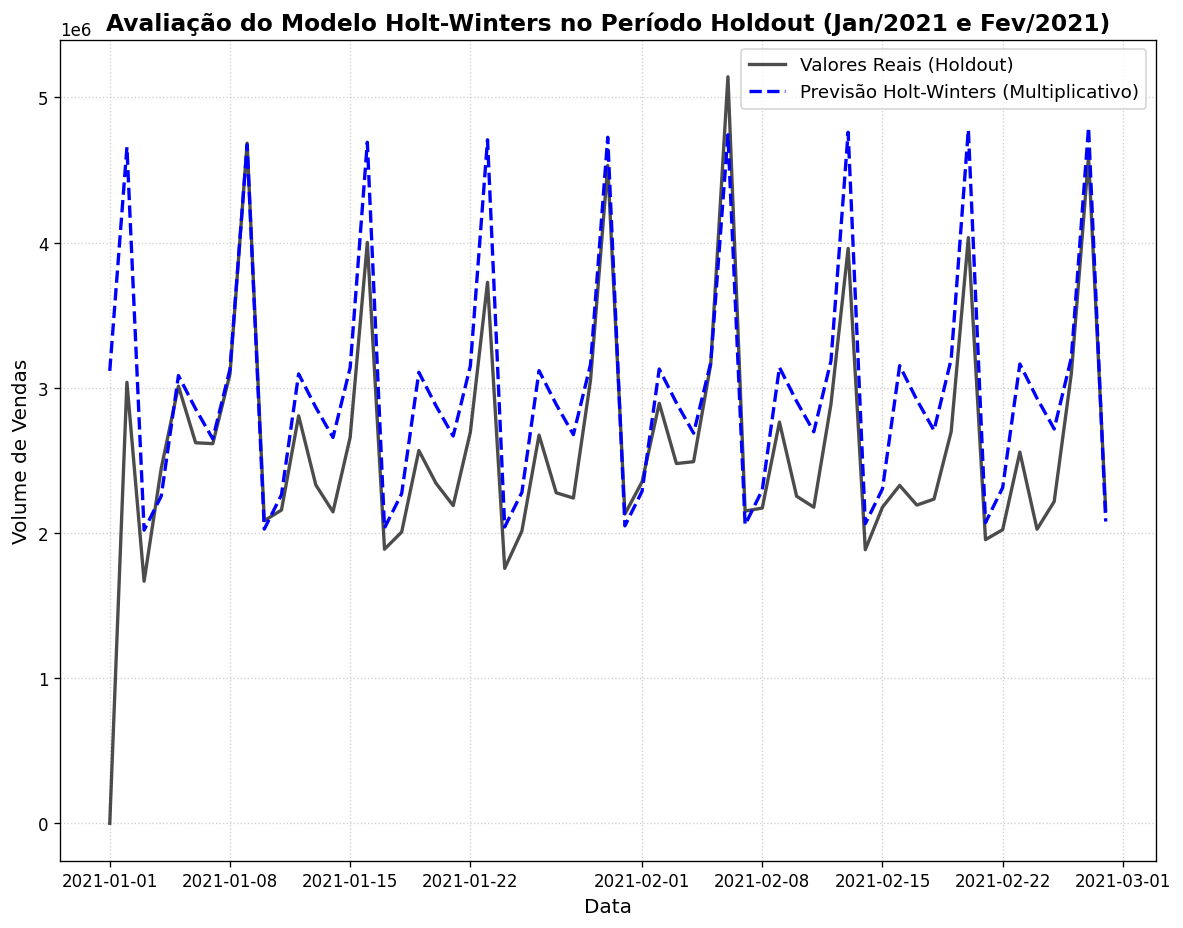

In [194]:
# Dados reais do período Holdout (Jan e Fev de 2021)
plt.plot(
    holdout.index,
    holdout['Vendas'],
    label='Valores Reais (Holdout)',
    color='black',
    linewidth=2,
    alpha=0.7
)

# Linha com a previsão gerada pelo Holt-Winters
plt.plot(
    previsao_hw.index,
    previsao_hw,
    label='Previsão Holt-Winters (Multiplicativo)',
    color='blue',
    linestyle='--',
    linewidth=2
)

plt.title('Avaliação do Modelo Holt-Winters no Período Holdout (Jan/2021 e Fev/2021)', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Volume de Vendas', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

# Ajusta as margens para não cortar as legendas e datas
plt.tight_layout()
plt.show()

In [196]:
# CÁLCULO DAS MÉTRICAS NO PERÍODO DE TESTE (HOLDOUT)
# Calculando os erros reais entre o Holt-Winters e o Holdout
mae_hw = mean_absolute_error(holdout['Vendas'], previsao_hw)
mape_hw = mean_absolute_percentage_error(holdout['Vendas'], previsao_hw)
rmse_hw = sqrt(mean_squared_error(holdout['Vendas'], previsao_hw))

print("--- AVALIAÇÃO DO HOLT-WINTERS NO PERÍODO DE TESTE ---")
print(f"MAE  (Erro Médio Absoluto): {mae_hw:,.2f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse_hw:,.2f}")
print(f"MAPE (Erro Percentual Absoluto Médio): {mape_hw * 100:.2f}%")
print("-" * 50)

--- AVALIAÇÃO DO HOLT-WINTERS NO PERÍODO DE TESTE ---
MAE  (Erro Médio Absoluto): 418,908.91
RMSE (Raiz do Erro Quadrático Médio): 622,043.27
MAPE (Erro Percentual Absoluto Médio): 5281811.91%
--------------------------------------------------


In [198]:
# Filtra apenas os dias onde as vendas reais são maiores que 1 (removendo os "zeros" das viradas de ano)
holdout_sem_zero = holdout[holdout['Vendas'] > 1]
previsao_hw_sem_zero = previsao_hw[holdout_sem_zero.index]

# Recalcula o MAPE ajustado
mape_ajustado = mean_absolute_percentage_error(holdout_sem_zero['Vendas'], previsao_hw_sem_zero)

print(f"MAPE Ajustado (Sem os dias zero): {mape_ajustado * 100:.2f}%")

MAPE Ajustado (Sem os dias zero): 14.57%


In [200]:
# Cálculo do WAPE
wape_hw = np.sum(np.abs(holdout['Vendas'] - previsao_hw)) / np.sum(holdout['Vendas'])
print(f"WAPE (Erro Percentual Ponderado): {wape_hw * 100:.2f}%")

WAPE (Erro Percentual Ponderado): 16.00%


In [199]:
# ANÁLISE DE RUÍDO BRANCO NOS RESÍDUOS DO MODELO

residuos_hw = modelo_hw.resid

# Teste de Ljung-Box nos resíduos (Normalmente checamos até o lag 7 por ser semanal)
resultado_lb_residuos = acorr_ljungbox(residuos_hw, lags=[7], return_df=True)

print("\n--- TESTE DE LJUNG-BOX NOS RESÍDUOS (VERIFICAÇÃO DE RUÍDO BRANCO) ---")
print(resultado_lb_residuos)

p_valor_residuos = resultado_lb_residuos['lb_pvalue'].values[0]
if p_valor_residuos > 0.05:
    print(f"\np-valor = {p_valor_residuos:.5f} (>= 0.05).")
    print("Os resíduos SÃO Ruído Branco! O modelo capturou perfeitamente todos os padrões temporais. 🎯")
else:
    print(f"\np-valor = {p_valor_residuos:.5f} (< 0.05).")
    print("Os resíduos NÃO são Ruído Branco. O modelo ainda deixou alguma informação para trás. ⚠️")


--- TESTE DE LJUNG-BOX NOS RESÍDUOS (VERIFICAÇÃO DE RUÍDO BRANCO) ---
      lb_stat     lb_pvalue
7  108.014351  2.369870e-20

p-valor = 0.00000 (< 0.05).
Os resíduos NÃO são Ruído Branco. O modelo ainda deixou alguma informação para trás. ⚠️


## **8.2 ARIMA:**

Como já foi visto pelo teste ADF que a série precisa de uma diferenciação para ficar estacionária ($d=1$), deve-se analisar o ACF e o PACF da série já diferenciada para descobrir os parâmetros corretos.

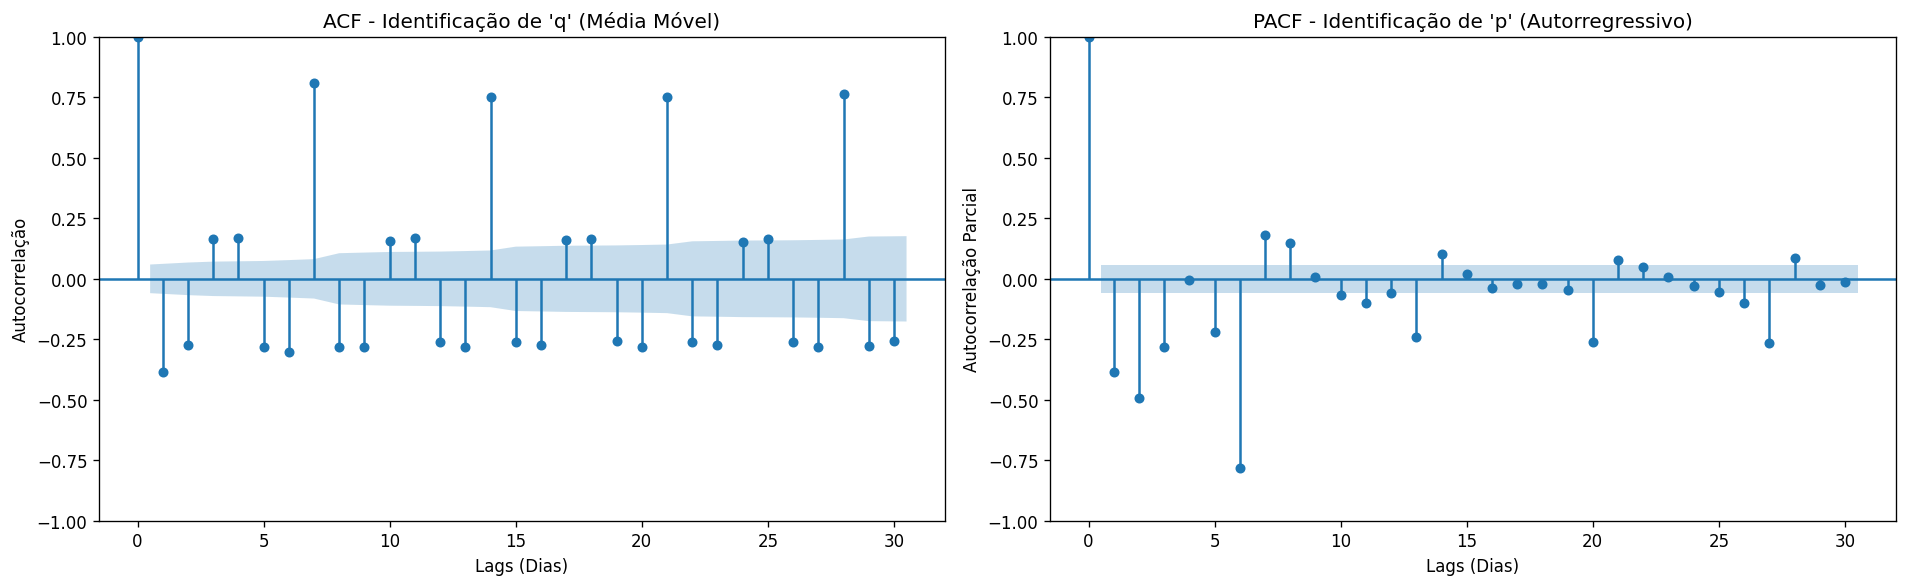

In [204]:
# Aplicando a primeira diferenciação na base de treino para estacionarizar a série
serie_diferenciada = treino['Vendas'].diff().dropna()

# Criando a estrutura de subplots lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), dpi=120)

# Plot do ACF (para identificar o termo de Média Móvel - q)
plot_acf(serie_diferenciada, lags=30, ax=ax1, title="ACF - Identificação de 'q' (Média Móvel)")
ax1.set_xlabel("Lags (Dias)")
ax1.set_ylabel("Autocorrelação")

# Plot do PACF (para identificar o termo Autorregressivo - p)
plot_pacf(serie_diferenciada, lags=30, ax=ax2, title="PACF - Identificação de 'p' (Autorregressivo)", method='yule_walker')
ax2.set_xlabel("Lags (Dias)")
ax2.set_ylabel("Autocorrelação Parcial")

plt.tight_layout()
plt.show()

In [219]:
# Treinando o ARIMA Tradicional com os parâmetros identificados
modelo_arima = ARIMA(
    treino['Vendas'],
    order=(3, 1, 2),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [220]:
print(modelo_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                 Vendas   No. Observations:                 1095
Model:                 ARIMA(3, 1, 2)   Log Likelihood              -16182.578
Date:                Thu, 16 Jul 2026   AIC                          32377.157
Time:                        02:18:40   BIC                          32407.126
Sample:                    01-02-2018   HQIC                         32388.499
                         - 12-31-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8894      0.055    -16.044      0.000      -0.998      -0.781
ar.L2         -0.2897      0.052     -5.604      0.000      -0.391      -0.188
ar.L3         -0.1528      0.050     -3.050      0.0

1) Parte Autorregressiva:

(ar.L1, ar.L2, ar.L3): Todos deram 0.000 ou 0.002. Isso significa que os três lags passados de curto prazo são estatisticamente fundamentais para explicar o comportamento de hoje. A inclusão do terceiro lag se pagou.

2) Parte de Média Móvel (ma.L1 e ma.L2):

O ma.L2 é altamente significativo (0.000), mostrando que o choque de dois dias atrás é crucial.

Contudo, o ma.L1 ficou com um p-valor de 0.184 (maior que 0.05). Isso nos indica que, na presença do lag 2 e dos termos AR, o erro de 1 dia atrás isolado não está adicionando informação estatisticamente relevante.

Warnings:

Esse aviso é a prova definitiva de que aumentar ou mudar os parâmetros no ARIMA tradicional não vai resolver o problema. A solução para sumir com essa redundância e com o aviso é:

Reduzir a complexidade não sazonal: Simplificar os termos de curto prazo (usando ordens menores como 1 ou 2).

Ativar o componente Sazonal (SARIMA): Dizer explicitamente ao modelo que existe um ciclo de 7 dias. Isso isola o padrão semanal dos choques diários, eliminando a confusão matemática.

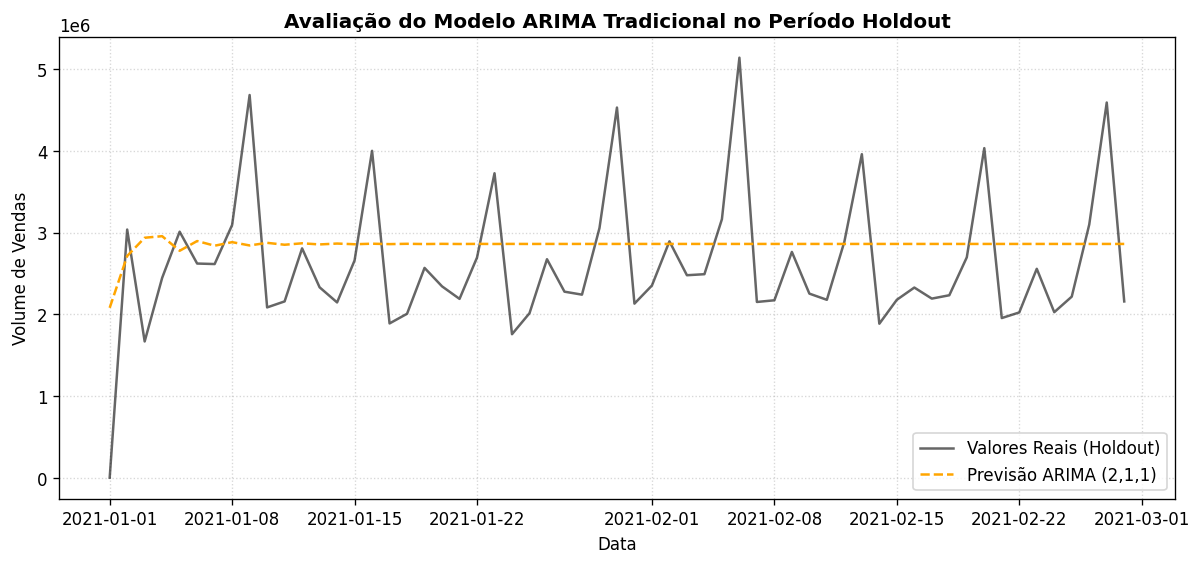

In [221]:
# Gerando as previsões para o período de teste (holdout)
previsao_arima = modelo_arima.forecast(steps=passos_holdout)
previsao_arima.index = holdout.index

# VISUALIZAÇÃO GRÁFICA NO PERÍODO DE TESTE
plt.figure(figsize=(12, 5), dpi=120)
plt.plot(holdout.index, holdout['Vendas'], label='Valores Reais (Holdout)', color='black', alpha=0.6)
plt.plot(previsao_arima.index, previsao_arima, label='Previsão ARIMA (2,1,1)', color='orange', linestyle='--')
plt.title('Avaliação do Modelo ARIMA Tradicional no Período Holdout', fontsize=12, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Volume de Vendas')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

In [222]:
# ANÁLISE DE RUÍDO BRANCO NOS RESÍDUOS
residuos_arima = modelo_arima.resid
resultado_lb_arima = acorr_ljungbox(residuos_arima, lags=[7], return_df=True)

print("--- TESTE DE LJUNG-BOX NOS RESÍDUOS DO ARIMA ---")
print(resultado_lb_arima)

p_val_arima = resultado_lb_arima['lb_pvalue'].values[0]
if p_val_arima > 0.05:
    print(f"\np-valor = {p_val_arima:.5f}. Resíduos SÃO Ruído Branco!")
else:
    print(f"\np-valor = {p_val_arima:.5f}. Resíduos NÃO são Ruído Branco. (Esperado, pois ignoramos a sazonalidade!) ⚠️")

--- TESTE DE LJUNG-BOX NOS RESÍDUOS DO ARIMA ---
      lb_stat      lb_pvalue
7  494.705871  1.101781e-102

p-valor = 0.00000. Resíduos NÃO são Ruído Branco. (Esperado, pois ignoramos a sazonalidade!) ⚠️


# **8.3 SARIMA:**

In [223]:
modelo_sarima = ARIMA(
    treino['Vendas'],
    order=(3, 1, 2),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [224]:
print(modelo_sarima.summary())

                                     SARIMAX Results                                     
Dep. Variable:                            Vendas   No. Observations:                 1095
Model:             ARIMA(3, 1, 2)x(1, 1, [1], 7)   Log Likelihood              -15458.821
Date:                           Thu, 16 Jul 2026   AIC                          30933.642
Time:                                   02:21:33   BIC                          30973.498
Sample:                               01-02-2018   HQIC                         30948.735
                                    - 12-31-2020                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8584      0.037    -22.978      0.000      -0.932      -0.785
ar.L2          0.1708      0.070      2.453

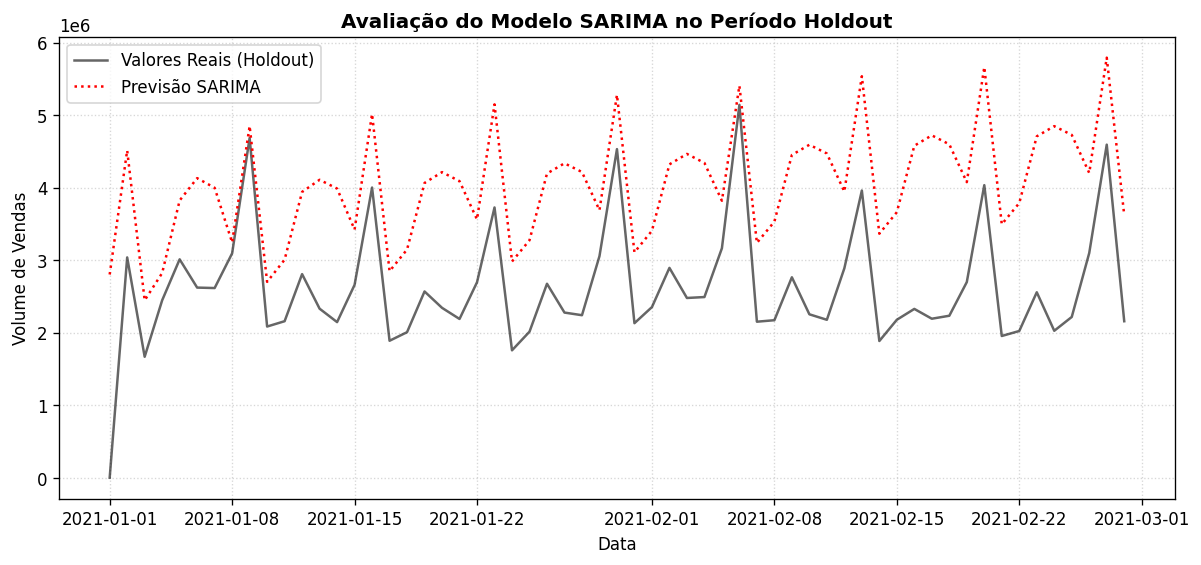

In [225]:
# Gerando as previsões para o holdout
previsao_sarima = modelo_sarima.forecast(steps=passos_holdout)
previsao_sarima.index = holdout.index

# Gráfico no Holdout
plt.figure(figsize=(12, 5), dpi=120)
plt.plot(holdout.index, holdout['Vendas'], label='Valores Reais (Holdout)', color='black', alpha=0.6)
plt.plot(previsao_sarima.index, previsao_sarima, label='Previsão SARIMA', color='red', linestyle=':')
plt.title('Avaliação do Modelo SARIMA no Período Holdout', fontsize=12, fontweight='bold')
plt.xlabel('Data')
plt.ylabel('Volume de Vendas')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

In [226]:
# Teste de Ruído Branco nos resíduos
residuos_sarima = modelo_sarima.resid
resultado_lb_sarima = acorr_ljungbox(residuos_sarima, lags=[7], return_df=True)
print("\n--- TESTE DE LJUNG-BOX (RUÍDO BRANCO SARIMA) ---")
print(resultado_lb_sarima)


--- TESTE DE LJUNG-BOX (RUÍDO BRANCO SARIMA) ---
     lb_stat  lb_pvalue
7  11.101837   0.134238
